In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Everything works!")

Everything works!


In [2]:
FILE_PATH = Path("customer_data.xlsx")

In [3]:
print(FILE_PATH.exists())

True


In [4]:
df = pd.read_excel(FILE_PATH)

In [5]:
display(df.head())

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [6]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (60, 17)
Columns:
['customer_id', 'first_name', 'gender', 'age', 'city', 'province', 'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days', 'payment_method', 'device', 'discount_used', 'returned_items', 'satisfaction_score']


In [7]:
required_columns = [
    "customer_id",
    "first_name",
    "gender",
    "age",
    "city",
    "province",
    "signup_date",
    "membership_tier",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "payment_method",
    "device",
    "discount_used",
    "returned_items",
    "satisfaction_score"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"These required columns are missing: {missing_columns}"
    )

print("All required columns are present.")

All required columns are present.


In [8]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    errors="coerce"
)

In [9]:
numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [10]:
text_columns = [
    "first_name",
    "gender",
    "city",
    "province",
    "membership_tier",
    "payment_method",
    "device",
    "discount_used"
]

for col in text_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
    )

In [11]:
print("Dataset shape:", df.shape)

print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

print("\nMissing values by column:")
print(
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

display(df.head())

Dataset shape: (60, 17)
Number of duplicate rows: 0

Missing values by column:
customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [12]:
analysis_df = df.dropna(
    subset=[
        "gender",
        "age",
        "membership_tier",
        "device",
        "payment_method"
    ]
).copy()

print("Customers included in Question 1:", len(analysis_df))

Customers included in Question 1: 60


In [13]:
age_bins = [0, 24, 34, 44, 54, 64, np.inf]

age_labels = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

analysis_df["age_group"] = pd.cut(
    analysis_df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [14]:
age_counts = analysis_df["age_group"].value_counts(sort=False)

display(age_counts)

age_group
Under 25     7
25-34       11
35-44       10
45-54       15
55-64       16
65+          1
Name: count, dtype: int64

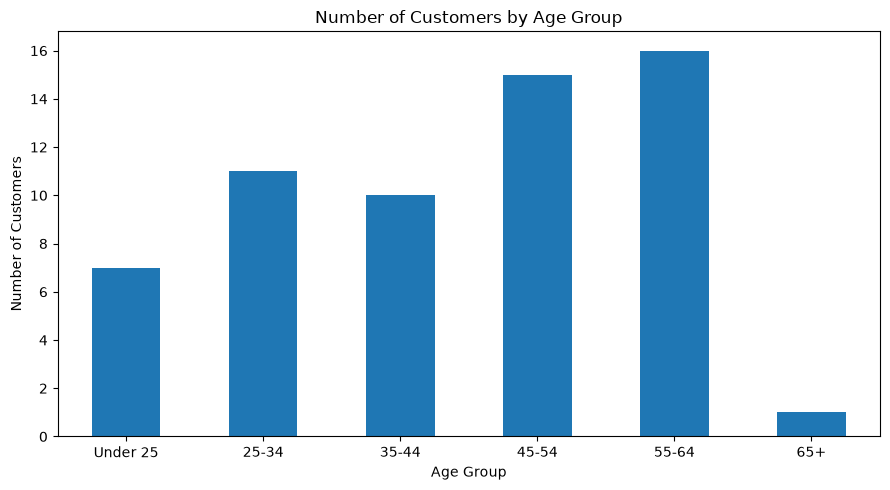

In [15]:
plt.figure(figsize=(9, 5))

age_counts.plot(kind="bar")

plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
profile_summary = {
    "Number of customers": analysis_df["customer_id"].nunique(),
    "Average age": analysis_df["age"].mean(),
    "Median age": analysis_df["age"].median(),
    "Most common gender": analysis_df["gender"].mode().iloc[0],
    "Most common membership tier": analysis_df["membership_tier"].mode().iloc[0],
    "Most common device": analysis_df["device"].mode().iloc[0],
    "Most common payment method": analysis_df["payment_method"].mode().iloc[0]
}

profile_table = pd.Series(
    profile_summary,
    name="Value"
)

display(profile_table)

Number of customers                       60
Average age                             43.7
Median age                              45.0
Most common gender                         F
Most common membership tier             Gold
Most common device                   Android
Most common payment method     Online Wallet
Name: Value, dtype: object

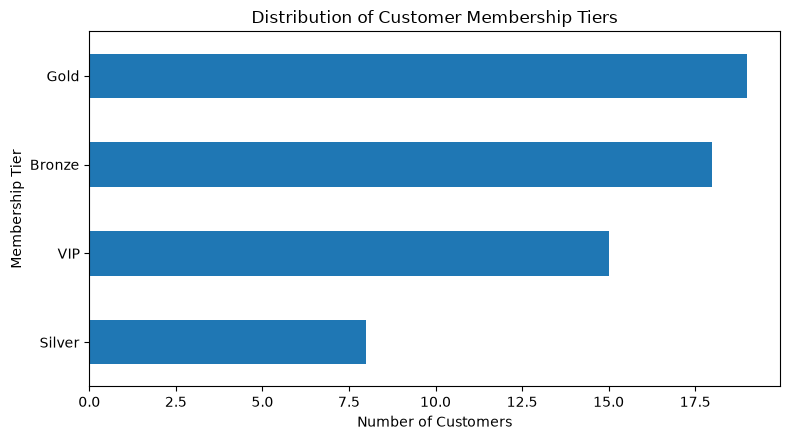

In [17]:
membership_counts = (
    analysis_df["membership_tier"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4.5))

membership_counts.plot(kind="barh")

plt.title("Distribution of Customer Membership Tiers")
plt.xlabel("Number of Customers")
plt.ylabel("Membership Tier")

plt.tight_layout()
plt.show()

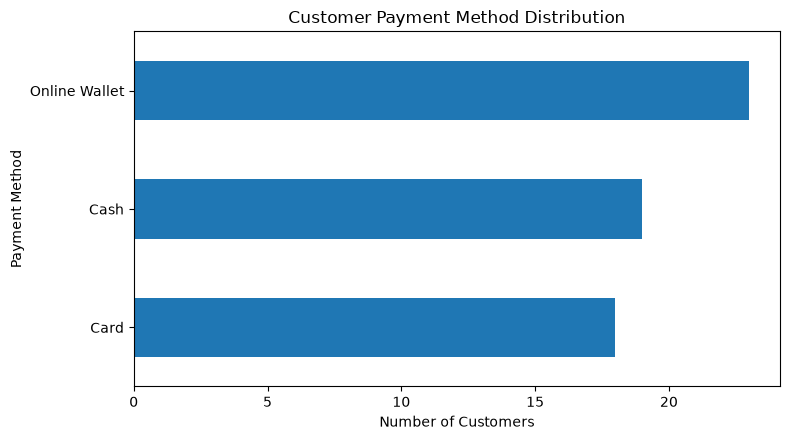

In [18]:
payment_counts = (
    analysis_df["payment_method"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4.5))

payment_counts.plot(kind="barh")

plt.title("Customer Payment Method Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

In [19]:
membership_value = (
    analysis_df
    .groupby("membership_tier")
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
    .sort_values("avg_spending", ascending=False)
)

display(membership_value)

,customer_count,avg_spending,avg_purchase_count,avg_satisfaction
membership_tier,,,,
Silver,8,4179.926250,16.500000,2.500000
Gold,19,3955.431579,17.052632,2.736842
Bronze,18,3166.656111,16.888889,3.111111
VIP,15,2426.220667,18.866667,3.400000


In [20]:
device_value = (
    analysis_df
    .groupby("device")
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
    .sort_values("avg_spending", ascending=False)
)

display(device_value)

,customer_count,avg_spending,avg_purchase_count,avg_satisfaction
device,,,,
iPhone,18,3773.945000,18.277778,2.944444
Android,22,3459.069091,17.909091,3.090909
Web,20,2897.760000,16.000000,2.900000


In [21]:
payment_value = (
    analysis_df
    .groupby("payment_method")
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
    .sort_values("avg_spending", ascending=False)
)

display(payment_value)

,customer_count,avg_spending,avg_purchase_count,avg_satisfaction
payment_method,,,,
Card,18,3929.005000,18.777778,3.277778
Cash,19,3150.579474,19.210526,3.473684
Online Wallet,23,3104.462174,14.782609,2.347826


In [22]:
analysis_df["gender"].value_counts()

gender
F    35
M    25
Name: count, dtype: Int64

In [23]:
analysis_df.groupby("gender").agg(
    customer_count=("customer_id", "nunique"),
    avg_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
).sort_values("avg_spending", ascending=False)

,customer_count,avg_spending,avg_purchase_count,avg_satisfaction
gender,,,,
M,25,4097.9048,18.360000,3.000000
F,35,2843.9460,16.685714,2.971429


In [ ]:
analysis_df.groupby("payment_method").agg(
    customer_count=("customer_id", "nunique"),
    avg_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
).sort_values("avg_spending", ascending=False)

In [24]:
location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "satisfaction_score"
    ]
).copy()

city_summary = (
    location_df
    .groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

city_summary = city_summary[
    city_summary["customer_count"] >= 3
].copy()

top_cities = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

display(top_cities.sort_values("total_revenue", ascending=False))

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
6,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,216.531250,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


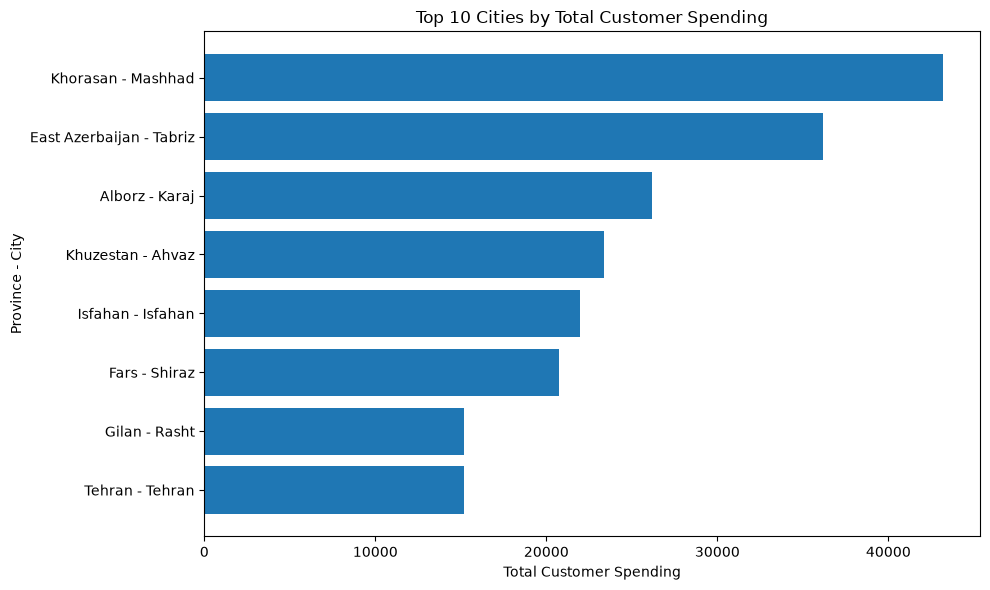

In [25]:
labels = top_cities["province"] + " - " + top_cities["city"]

plt.figure(figsize=(10, 6))

plt.barh(
    labels,
    top_cities["total_revenue"]
)

plt.title("Top 10 Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")
plt.ylabel("Province - City")

plt.tight_layout()
plt.show()

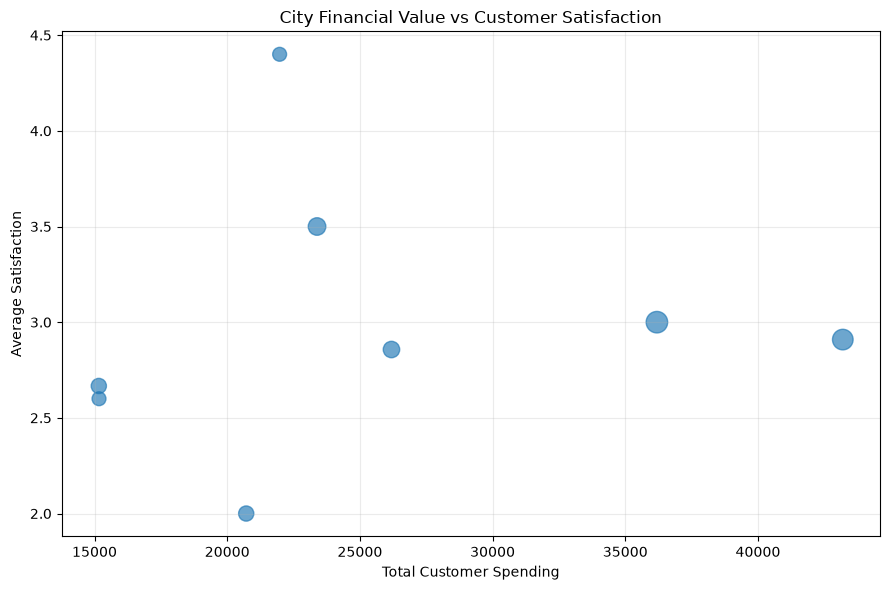

In [26]:
plt.figure(figsize=(9, 6))

plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.65
)

plt.title("City Financial Value vs Customer Satisfaction")
plt.xlabel("Total Customer Spending")
plt.ylabel("Average Satisfaction")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [27]:
recommended_city = city_summary.sort_values(
    ["total_revenue", "avg_satisfaction", "customer_count"],
    ascending=[False, False, False]
).head(1)

display(recommended_city)

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091


In [1]:
plt.figure(figsize=(10, 7))

plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 30,
    alpha=0.65
)

# Add city names to each point
for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.title("City Financial Value vs Customer Satisfaction")
plt.xlabel("Total Customer Spending")
plt.ylabel("Average Satisfaction")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

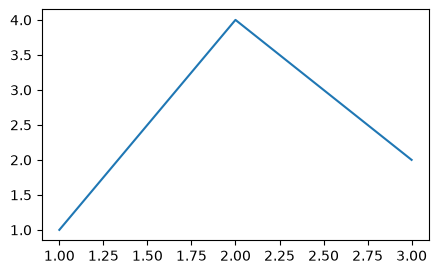

In [3]:
plt.figure(figsize=(5, 3))
plt.plot([1, 2, 3], [1, 4, 2])
plt.show()

In [4]:
plt.figure(figsize=(10, 7))

plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 40,
    alpha=0.65
)

# Add city names to each point
for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.title("City Revenue vs. Customer Satisfaction")
plt.xlabel("Total Revenue")
plt.ylabel("Average Satisfaction")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

NameError: name 'city_summary' is not defined

<Figure size 1000x700 with 0 Axes>

In [5]:
df.head()

NameError: name 'df' is not defined

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "satisfaction_score"
    ]
).copy()

NameError: name 'df' is not defined

In [8]:
FILE_PATH = Path("customer_data.xlsx")

In [9]:
print(FILE_PATH.exists())

True


In [10]:
df = pd.read_excel(FILE_PATH)

In [11]:
location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "satisfaction_score"
    ]
).copy()

In [12]:
city_summary

NameError: name 'city_summary' is not defined

In [13]:
city_summary = (
    location_df.groupby(
        ["province", "city"],
        as_index=False
    )
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

city_summary = city_summary[
    city_summary["customer_count"] >= 3
].copy()

city_summary

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091
6,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,216.531250,3.500000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


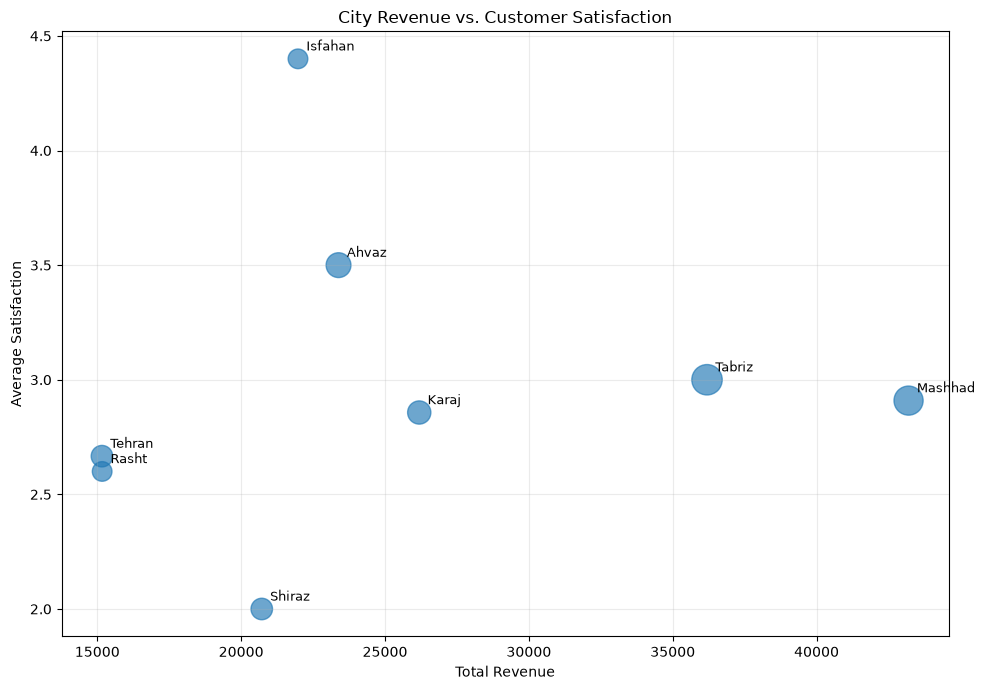

In [14]:
plt.figure(figsize=(10, 7))

plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 40,
    alpha=0.65
)

for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.title("City Revenue vs. Customer Satisfaction")
plt.xlabel("Total Revenue")
plt.ylabel("Average Satisfaction")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [15]:
loyalty_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
).copy()

print("Number of customers analyzed:", loyalty_df["customer_id"].nunique())

Number of customers analyzed: 60


In [16]:
loyalty_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
).copy()

print("Number of customers analyzed:", loyalty_df["customer_id"].nunique())

Number of customers analyzed: 60


In [17]:
for column in [
    "purchase_count",
    "total_spending",
    "satisfaction_score"
]:
    minimum = loyalty_df[column].min()
    maximum = loyalty_df[column].max()

    if maximum == minimum:
        loyalty_df[f"{column}_score"] = 1.0
    else:
        loyalty_df[f"{column}_score"] = (
            loyalty_df[column] - minimum
        ) / (maximum - minimum)

In [18]:
recency_min = loyalty_df["last_purchase_days"].min()
recency_max = loyalty_df["last_purchase_days"].max()

if recency_max == recency_min:
    loyalty_df["recency_score"] = 1.0
else:
    loyalty_df["recency_score"] = 1 - (
        (loyalty_df["last_purchase_days"] - recency_min)
        / (recency_max - recency_min)
    )

In [19]:
loyalty_df["loyalty_score"] = (
    0.35 * loyalty_df["total_spending_score"]
    + 0.30 * loyalty_df["purchase_count_score"]
    + 0.20 * loyalty_df["recency_score"]
    + 0.15 * loyalty_df["satisfaction_score_score"]
)

In [20]:
top_loyal_customers = loyalty_df.nlargest(
    10,
    "loyalty_score"
)[[
    "customer_id",
    "first_name",
    "membership_tier",
    "purchase_count",
    "total_spending",
    "last_purchase_days",
    "satisfaction_score",
    "loyalty_score"
]]

display(top_loyal_customers)

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Bronze,31,13532.74,82,4,0.864535
43,1044,Mina,Gold,33,14354.34,165,2,0.780854
58,1059,Ali,Gold,31,8898.55,224,5,0.710587
8,1009,Kimia,Silver,34,11615.42,232,2,0.685627
3,1004,Sina,Gold,23,6121.45,40,4,0.638459
11,1012,Arash,Gold,27,11731.50,224,2,0.632877
32,1033,Neda,VIP,24,5521.20,112,5,0.630116
13,1014,Reza,VIP,31,3353.89,97,4,0.608058
22,1023,Ali,Bronze,31,3851.44,170,4,0.579858
16,1017,Parsa,VIP,30,3239.40,135,4,0.575701


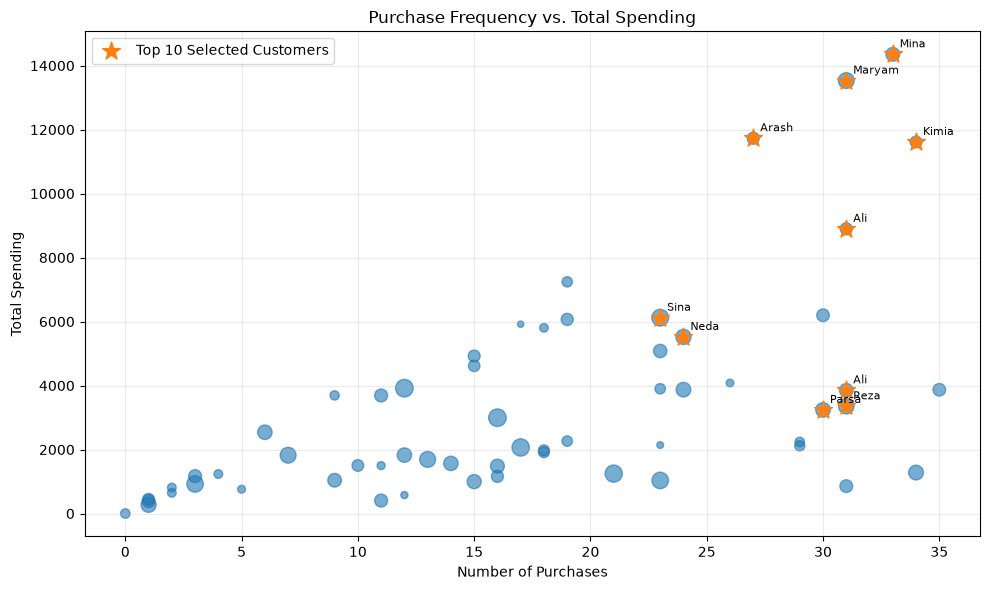

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["total_spending"],
    s=(loyalty_df["recency_score"] + 0.15) * 140,
    alpha=0.6
)

plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["total_spending"],
    s=180,
    marker="*",
    label="Top 10 Selected Customers"
)

for _, row in top_loyal_customers.iterrows():
    plt.annotate(
        row["first_name"],
        (row["purchase_count"], row["total_spending"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Purchase Frequency vs. Total Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [12]:
risk_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "total_spending",
        "purchase_count",
        "last_purchase_days"
    ]
).copy()

In [23]:
spending_threshold = risk_df["total_spending"].quantile(0.75)

purchase_threshold = risk_df["purchase_count"].median()

inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)

In [24]:
risk_df["at_risk"] = (
    (risk_df["total_spending"] >= spending_threshold)
    & (risk_df["purchase_count"] >= purchase_threshold)
    & (risk_df["last_purchase_days"] >= inactivity_threshold)
)

In [25]:
at_risk = True

In [26]:
at_risk_customers = risk_df.loc[
    risk_df["at_risk"],
    [
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
].sort_values(
    ["total_spending", "last_purchase_days"],
    ascending=[False, False]
)

In [27]:
display(at_risk_customers)

print("Number of at-risk customers:", len(at_risk_customers))

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Silver,19,7241.47,276,1
34,1035,Arash,Bronze,17,5918.21,365,3
52,1053,Sina,Gold,18,5805.54,320,1


Number of at-risk customers: 3


In [28]:
print("Spending threshold:", spending_threshold)
print("Purchase threshold:", purchase_threshold)
print("Inactivity threshold:", inactivity_threshold)

Spending threshold: 4213.1175
Purchase threshold: 17.0
Inactivity threshold: 273.75


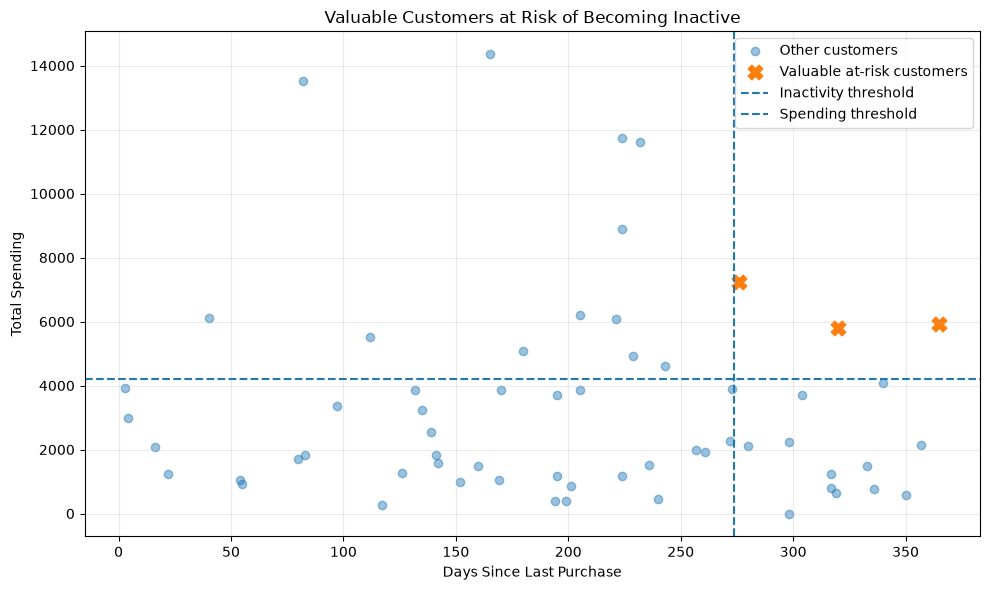

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.45,
    label="Other customers"
)

plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X",
    s=110,
    label="Valuable at-risk customers"
)

plt.axvline(
    inactivity_threshold,
    linestyle="--",
    label="Inactivity threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label="Spending threshold"
)

plt.title("Valuable Customers at Risk of Becoming Inactive")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [30]:
factor_df = df.dropna(
    subset=[
        "discount_used",
        "device",
        "payment_method",
        "total_spending",
        "purchase_count",
        "avg_order_value",
        "returned_items",
        "satisfaction_score"
    ]
).copy()

In [33]:
summary_by_discount = (
    factor_df.groupby("discount_used", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

display(summary_by_discount)

,discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,34,3736.741176,17.294118,220.700588,3.970588,2.764706
1,Yes,26,2882.174231,17.500000,203.291154,3.576923,3.269231


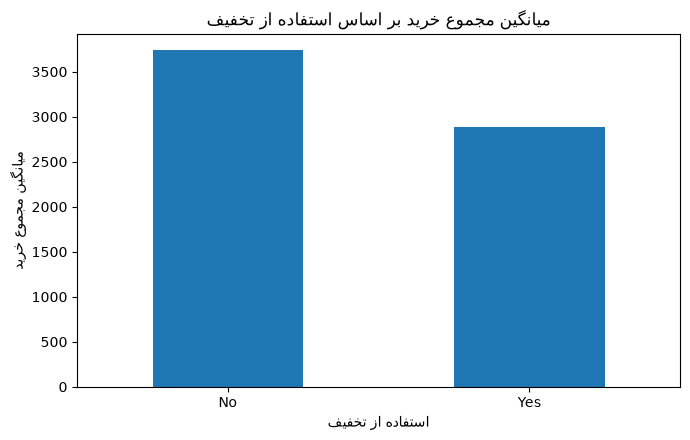

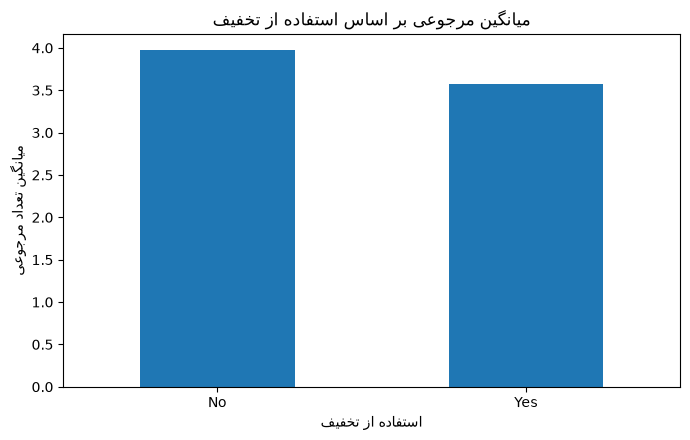

In [35]:
metrics = [
    ("avg_total_spending", "میانگین مجموع خرید بر اساس استفاده از تخفیف", "میانگین مجموع خرید"),
    ("avg_returned_items", "میانگین مرجوعی بر اساس استفاده از تخفیف", "میانگین تعداد مرجوعی")
]

for metric, title, ylabel in metrics:
    summary_by_discount.plot(
        x="discount_used",
        y=metric,
        kind="bar",
        legend=False,
        figsize=(7, 4.5)
    )

    plt.title(title)
    plt.xlabel("استفاده از تخفیف")
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [37]:
for factor, title in [
    ("device", "میانگین مجموع خرید بر اساس دستگاه"),
    ("payment_method", "میانگین مجموع خرید بر اساس روش پرداخت")
]:factor_summary = (
    factor_df.groupby(factor)["total_spending"]
    .agg(["count", "mean"])
    .query("count >= 3")
    .sort_values("mean", ascending=True)
)

In [38]:
display(factor_summary)

,count,mean
payment_method,,
Online Wallet,23,3104.462174
Cash,19,3150.579474
Card,18,3929.005000


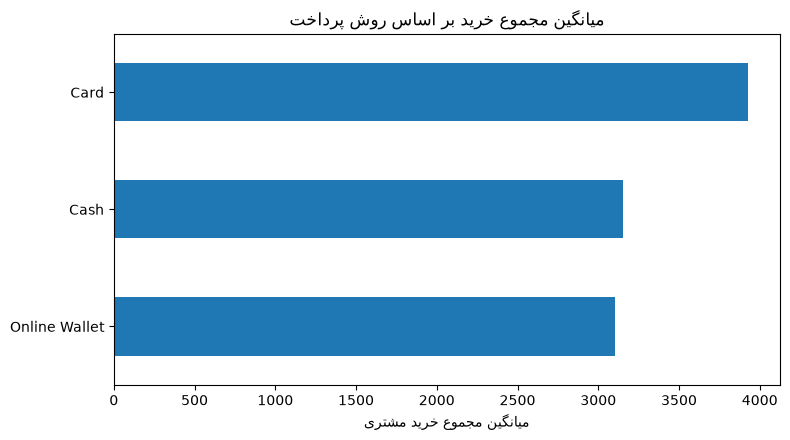

In [40]:
factor_summary["mean"].plot(
    kind="barh",
    figsize=(8, 4.5)
)
plt.title(title)
plt.xlabel("میانگین مجموع خرید مشتری")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [41]:
kpi_summary = pd.Series({
    "تعداد مشتریان یکتا": df["customer_id"].nunique(),
    "مجموع خرید مشتریان": df["total_spending"].sum(),
    "میانگین مجموع خرید هر مشتری": df["total_spending"].mean(),
    "میانگین تعداد خرید": df["purchase_count"].mean(),
    "میانگین رضایت": df["satisfaction_score"].mean(),
    "مجموع کالاهای مرجوع‌شده": df["returned_items"].sum()
}, name="مقدار")

display(kpi_summary)

تعداد مشتریان یکتا                 60.000000
مجموع خرید مشتریان             201985.730000
میانگین مجموع خرید هر مشتری      3366.428833
میانگین تعداد خرید                 17.383333
میانگین رضایت                       2.983333
مجموع کالاهای مرجوع‌شده           228.000000
Name: مقدار, dtype: float64

In [3]:
chart1 = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")

chart1_labels = chart1["province"] + " - " + chart1["city"]

plt.figure(figsize=(10, 6))

plt.barh(chart1_labels, chart1["total_revenue"])

plt.title("۱۰ شهر برتر بر اساس مجموع خرید")
plt.xlabel("مجموع خرید مشتریان")

plt.tight_layout()

plt.show()

NameError: name 'city_summary' is not defined

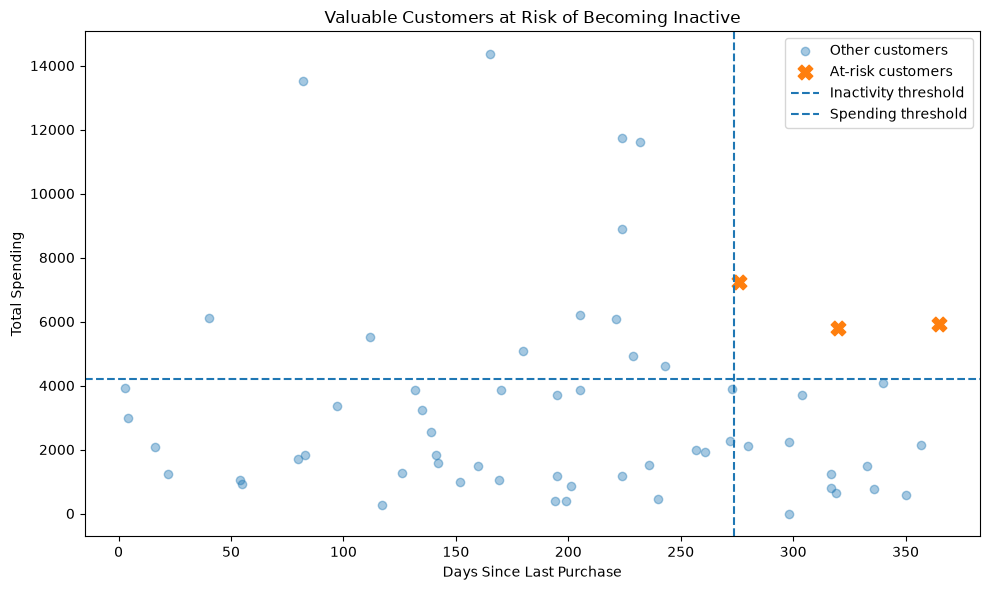

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.4,
    label="Other customers"
)

plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X",
    s=110,
    label="At-risk customers"
)

plt.axvline(
    inactivity_threshold,
    linestyle="--",
    label="Inactivity threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label="Spending threshold"
)

plt.title("Valuable Customers at Risk of Becoming Inactive")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")

plt.legend()

plt.tight_layout()
plt.show()

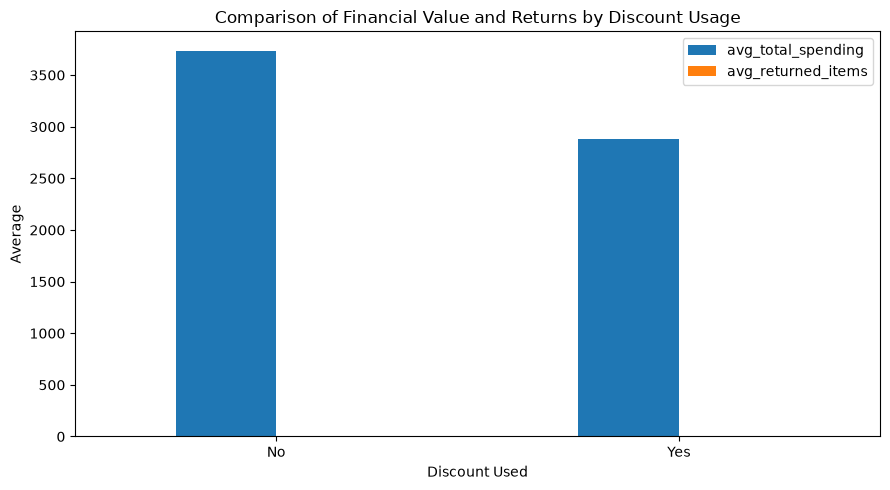

In [44]:
summary_by_discount.plot(
    x="discount_used",
    y=["avg_total_spending", "avg_returned_items"],
    kind="bar",
    figsize=(9, 5)
)

plt.title("Comparison of Financial Value and Returns by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
with pd.ExcelWriter("customer_analytics_results.xlsx") as writer:

    kpi_summary.to_excel(
        writer,
        sheet_name="KPI"
    )

    city_summary.to_excel(
        writer,
        sheet_name="City Analysis",
        index=False
    )

    top_loyal_customers.to_excel(
        writer,
        sheet_name="Top Loyal Customers",
        index=False
    )

    at_risk_customers.to_excel(
        writer,
        sheet_name="At Risk Customers",
        index=False
    )

    summary_by_discount.to_excel(
        writer,
        sheet_name="Discount Analysis",
        index=False
    )

print("File customer_analytics_results.xlsx saved.")

PermissionError: [Errno 13] Permission denied: 'customer_analytics_results.xlsx'

In [4]:
# ============================================================
# FINAL OUTPUTS: SAVE RESULTS AND FIGURES
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

# Create output folders if they don't already exist
Path("figures").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)


# ============================================================
# 1. RECREATE CITY SUMMARY
# ============================================================

location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "purchase_count",
        "avg_order_value",
        "satisfaction_score"
    ]
)

city_summary = (
    location_df
    .groupby(["province", "city"])
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
    .reset_index()
)


# ============================================================
# 2. SAVE CITY SUMMARY
# ============================================================

city_summary.to_excel(
    "results/city_summary.xlsx",
    index=False
)


# ============================================================
# 3. SAVE CUSTOMER RISK DATA
# ============================================================

risk_df.to_excel(
    "results/customer_risk.xlsx",
    index=False
)


# ============================================================
# 4. SAVE DISCOUNT SUMMARY
# ============================================================

summary_by_discount.to_excel(
    "results/discount_summary.xlsx",
    index=False
)


# ============================================================
# 5. FIGURE 1 — TOP CITIES
# ============================================================

chart1 = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

chart1_labels = (
    chart1["province"] + " - " + chart1["city"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart1_labels,
    chart1["total_revenue"]
)

plt.title("Top Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")

plt.tight_layout()

plt.savefig(
    "figures/top_cities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. FIGURE 2 — VALUABLE CUSTOMERS AT RISK
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df.loc[
        ~risk_df["at_risk"],
        "last_purchase_days"
    ],
    risk_df.loc[
        ~risk_df["at_risk"],
        "total_spending"
    ],
    alpha=0.4,
    label="Other customers"
)

plt.scatter(
    risk_df.loc[
        risk_df["at_risk"],
        "last_purchase_days"
    ],
    risk_df.loc[
        risk_df["at_risk"],
        "total_spending"
    ],
    marker="X",
    s=110,
    label="At-risk customers"
)

plt.title(
    "Valuable Customers at Risk of Becoming Inactive"
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/valuable_customers_at_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FIGURE 3 — DISCOUNT COMPARISON
# ============================================================

summary_by_discount.plot(
    x="discount_used",
    y=[
        "avg_total_spending",
        "avg_returned_items"
    ],
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Comparison of Spending and Returns by Discount Usage"
)

plt.xlabel("Discount Used")
plt.ylabel("Average")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "figures/discount_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. CONFIRM EVERYTHING WAS CREATED
# ============================================================

print("DONE!")
print()
print("Figures created:")
print("✓ figures/top_cities.png")
print("✓ figures/valuable_customers_at_risk.png")
print("✓ figures/discount_comparison.png")

print()
print("Result files created:")
print("✓ results/city_summary.xlsx")
print("✓ results/customer_risk.xlsx")
print("✓ results/discount_summary.xlsx")

NameError: name 'df' is not defined

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_excel("customer_data.xlsx")

In [7]:
print(df.shape)
df.head()

(60, 17)


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [8]:
print(df.columns.tolist())

['customer_id', 'first_name', 'gender', 'age', 'city', 'province', 'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days', 'payment_method', 'device', 'discount_used', 'returned_items', 'satisfaction_score']


In [9]:
location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "satisfaction_score"
    ]
).copy()

In [17]:
# ============================================================
# FINAL OUTPUTS: SAVE RESULTS AND FIGURES
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

# Create output folders if they don't already exist
Path("figures").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)


# ============================================================
# 1. RECREATE CITY SUMMARY
# ============================================================

location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "purchase_count",
        "avg_order_value",
        "satisfaction_score"
    ]
)

city_summary = (
    location_df
    .groupby(["province", "city"])
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
    .reset_index()
)


# ============================================================
# 2. SAVE CITY SUMMARY
# ============================================================

city_summary.to_excel(
    "results/city_summary.xlsx",
    index=False
)


# ============================================================
# 3. SAVE CUSTOMER RISK DATA
# ============================================================

risk_df.to_excel(
    "results/customer_risk.xlsx",
    index=False
)


# ============================================================
# 4. SAVE DISCOUNT SUMMARY
# ============================================================

summary_by_discount.to_excel(
    "results/discount_summary.xlsx",
    index=False
)


# ============================================================
# 5. FIGURE 1 — TOP CITIES
# ============================================================

chart1 = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

chart1_labels = (
    chart1["province"] + " - " + chart1["city"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart1_labels,
    chart1["total_revenue"]
)

plt.title("Top Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")

plt.tight_layout()

plt.savefig(
    "figures/top_cities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. FIGURE 2 — VALUABLE CUSTOMERS AT RISK
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df.loc[
        ~risk_df["at_risk"],
        "last_purchase_days"
    ],
    risk_df.loc[
        ~risk_df["at_risk"],
        "total_spending"
    ],
    alpha=0.4,
    label="Other customers"
)

plt.scatter(
    risk_df.loc[
        risk_df["at_risk"],
        "last_purchase_days"
    ],
    risk_df.loc[
        risk_df["at_risk"],
        "total_spending"
    ],
    marker="X",
    s=110,
    label="At-risk customers"
)

plt.title(
    "Valuable Customers at Risk of Becoming Inactive"
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/valuable_customers_at_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FIGURE 3 — DISCOUNT COMPARISON
# ============================================================

summary_by_discount.plot(
    x="discount_used",
    y=[
        "avg_total_spending",
        "avg_returned_items"
    ],
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Comparison of Spending and Returns by Discount Usage"
)

plt.xlabel("Discount Used")
plt.ylabel("Average")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "figures/discount_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. CONFIRM EVERYTHING WAS CREATED
# ============================================================

print("DONE!")
print()
print("Figures created:")
print("✓ figures/top_cities.png")
print("✓ figures/valuable_customers_at_risk.png")
print("✓ figures/discount_comparison.png")

print()
print("Result files created:")
print("✓ results/city_summary.xlsx")
print("✓ results/customer_risk.xlsx")
print("✓ results/discount_summary.xlsx")

NameError: name 'summary_by_discount' is not defined

In [11]:
print("risk_df" in globals())

False


In [13]:
risk_df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [14]:
risk_df.to_excel(
    "results/customer_risk.xlsx",
    index=False
)

In [19]:
# ============================================================
# FINAL OUTPUTS: SAVE RESULTS AND FIGURES
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

# Create output folders if they don't already exist
Path("figures").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)


# ============================================================
# 1. RECREATE CITY SUMMARY
# ============================================================

location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "purchase_count",
        "avg_order_value",
        "satisfaction_score"
    ]
)

city_summary = (
    location_df
    .groupby(["province", "city"])
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
    .reset_index()
)


# ============================================================
# 2. SAVE CITY SUMMARY
# ============================================================

city_summary.to_excel(
    "results/city_summary.xlsx",
    index=False
)


# ============================================================
# 3. SAVE CUSTOMER RISK DATA
# ============================================================

risk_df.to_excel(
    "results/customer_risk.xlsx",
    index=False
)


# ============================================================
# 4. SAVE DISCOUNT SUMMARY
# ============================================================

summary_by_discount.to_excel(
    "results/discount_summary.xlsx",
    index=False
)


# ============================================================
# 5. FIGURE 1 — TOP CITIES
# ============================================================

chart1 = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

chart1_labels = (
    chart1["province"] + " - " + chart1["city"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart1_labels,
    chart1["total_revenue"]
)

plt.title("Top Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")

plt.tight_layout()

plt.savefig(
    "figures/top_cities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. FIGURE 2 — VALUABLE CUSTOMERS AT RISK
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df.loc[
        ~risk_df["at_risk"],
        "last_purchase_days"
    ],
    risk_df.loc[
        ~risk_df["at_risk"],
        "total_spending"
    ],
    alpha=0.4,
    label="Other customers"
)

plt.scatter(
    risk_df.loc[
        risk_df["at_risk"],
        "last_purchase_days"
    ],
    risk_df.loc[
        risk_df["at_risk"],
        "total_spending"
    ],
    marker="X",
    s=110,
    label="At-risk customers"
)

plt.title(
    "Valuable Customers at Risk of Becoming Inactive"
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/valuable_customers_at_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FIGURE 3 — DISCOUNT COMPARISON
# ============================================================

summary_by_discount.plot(
    x="discount_used",
    y=[
        "avg_total_spending",
        "avg_returned_items"
    ],
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Comparison of Spending and Returns by Discount Usage"
)

plt.xlabel("Discount Used")
plt.ylabel("Average")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "figures/discount_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. CONFIRM EVERYTHING WAS CREATED
# ============================================================

print("DONE!")
print()
print("Figures created:")
print("✓ figures/top_cities.png")
print("✓ figures/valuable_customers_at_risk.png")
print("✓ figures/discount_comparison.png")

print()
print("Result files created:")
print("✓ results/city_summary.xlsx")
print("✓ results/customer_risk.xlsx")
print("✓ results/discount_summary.xlsx")

NameError: name 'summary_by_discount' is not defined